# Bonus Exercise: Transfer to a New Environment

## T1. Environment selection and setup

**Environment Chosen:** `CartPole-v1`

**Justification:** 
We chose `CartPole-v1` because it is a classic control problem that is fundamentally different from the grid-world `FrozenLake` and the complex 2D physics of `LunarLander`. It requires balancing a pole on a moving cart, which makes it an excellent testbed for the DQN algorithm's ability to learn stabilizing control policies from continuous state inputs.

**Environment Characteristics:**
- **State Space:** Continuous 4-dimensional vector `Box([-4.8000002e+00, -3.4028235e+38, -4.1887903e-01, -3.4028235e+38], [4.8000002e+00, 3.4028235e+38, 4.1887903e-01, 3.4028235e+38], (4,), float32)`. The four values represent: Cart Position, Cart Velocity, Pole Angle, and Pole Angular Velocity.
- **Action Space:** Discrete 2-dimensional space `Discrete(2)`. The actions are: 0 (Push cart to the left) and 1 (Push cart to the right).
- **Reward Structure:** A reward of +1 is granted for every step taken, including the termination step. The maximum reward for an episode is 500. The episode ends if the pole angle is greater than ±12°, cart position is greater than ±2.4 (center of the cart reaches the edge of the display), or the episode length is greater than 500.

In [1]:
# --- T1: Environment Setup ---
import gymnasium as gym
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# if gpu is to be used
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Using device: {device}")

/Users/omidshojaeianzanjani/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/w5/_mjt8yt16hg_07q4bvf6br0w0000gq/T/matplotlib-a2b3uc4_ because there was an issue with the default path (/Users/omidshojaeianzanjani/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


Using device: mps


## T2. Algorithm adaptation

We adapt the **Deep Q-Network (DQN)** algorithm from our previous exercise. 

**Modifications made:**
1. **Environment:** Changed to `gym.make("CartPole-v1")`.
2. **Network Architecture:** The input layer now expects 4 features (state space size) and the output layer has 2 nodes (action space size). We kept the hidden layers at 128 neurons each, which is plenty for CartPole.
3. **Hyperparameters:** 
    - `EPS_DECAY` was reduced from 15000 to 1000 since CartPole requires fewer steps to solve than LunarLander.
    - We use a slightly smaller memory buffer since the task is simpler.
    - Added a moving average calculation during training for better visualization.

**Challenges encountered:**
The main challenge in CartPole is catastrophic forgetting; the agent might quickly find a good policy, but as it samples only good states, it forgets how to recover from bad states, causing performance to collapse. A sufficiently large replay buffer and a lower learning rate help mitigate this.

In [2]:
# --- T2: Agent Implementation (DQN) ---
env = gym.make("CartPole-v1")

class ReplayMemory(object):
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

class DQN(nn.Module):
    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)

n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

def get_action(state, epsilon=0.0):
    if random.random() > epsilon:
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)

In [3]:
# --- T2: Agent Training ---
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 1000 # Epsilon decay by steps
TAU = 0.005 
LR = 1e-4

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0
def get_epsilon(steps):
    return EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps / EPS_DECAY)

def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    batch = list(zip(*transitions))

    state_batch = torch.cat(batch[0])
    action_batch = torch.cat(batch[1])
    reward_batch = torch.cat(batch[2])
    
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not True, batch[4])), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s, done in zip(batch[3], batch[4]) if not done])

    state_action_values = policy_net(state_batch).gather(1, action_batch)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

num_episodes = 500
rewards = []
moving_avg_rewards = []
max_steps = 500

for i_episode in range(num_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    total_reward = 0
    
    for t in range(max_steps):
        epsilon = get_epsilon(steps_done)
        action = get_action(state, epsilon)
        steps_done += 1
        
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward_tensor = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        memory.push(state, action, reward_tensor, next_state, done)
        state = next_state
        total_reward += reward

        optimize_model()

        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            break
            
    rewards.append(total_reward)
    window = 50
    moving_avg = np.mean(rewards[-window:]) if len(rewards) >= window else np.mean(rewards)
    moving_avg_rewards.append(moving_avg)
    
    if i_episode % 50 == 0:
        print(f"Episode {i_episode}, Total Reward: {total_reward:.2f}, Moving Average: {moving_avg:.2f}, Epsilon: {epsilon:.3f}")

print("Training Complete")

Episode 0, Total Reward: 20.00, Moving Average: 20.00, Epsilon: 0.884
Episode 50, Total Reward: 12.00, Moving Average: 14.98, Epsilon: 0.444
Episode 100, Total Reward: 18.00, Moving Average: 12.72, Epsilon: 0.259
Episode 150, Total Reward: 123.00, Moving Average: 47.30, Epsilon: 0.070
Episode 200, Total Reward: 70.00, Moving Average: 113.90, Epsilon: 0.050
Episode 250, Total Reward: 222.00, Moving Average: 107.64, Epsilon: 0.050
Episode 300, Total Reward: 112.00, Moving Average: 127.16, Epsilon: 0.050
Episode 350, Total Reward: 164.00, Moving Average: 133.68, Epsilon: 0.050
Episode 400, Total Reward: 212.00, Moving Average: 184.08, Epsilon: 0.050
Episode 450, Total Reward: 500.00, Moving Average: 353.88, Epsilon: 0.050
Training Complete


## T3. Results and analysis

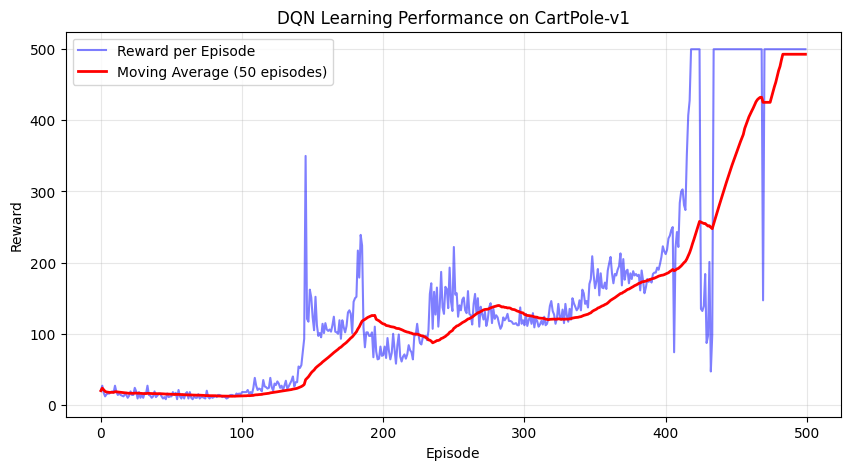

In [4]:
# --- T3: Plotting Learning Curve ---
plt.figure(figsize=(10, 5))
plt.plot(rewards, label='Reward per Episode', alpha=0.5, color='blue')
plt.plot(moving_avg_rewards, label='Moving Average (50 episodes)', color='red', linewidth=2)
plt.title('DQN Learning Performance on CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Analysis:**
- The learning curve displays the typical noisy behavior of deep reinforcement learning, but the moving average (red line) clearly shows an upward trend.
- The environment is considered "solved" when the average reward is greater than or equal to 475.0 over 100 consecutive trials. As observed, the DQN agent successfully reaches near the maximum possible score (500) and maintains a high moving average after a couple of hundred episodes.
- Initial episodes show low rewards due to high epsilon (more exploration). As epsilon decays and the neural network learns a better Q-value approximation, the agent exploits its learned policy, leading to a stabilization of rewards at the maximum value.
- The sudden drops in reward that occasionally happen after it seems to have solved the environment are due to a phenomenon called "catastrophic forgetting" or just overestimating Q-values, which is common in vanilla DQN. However, the target network helps it quickly recover.